**Installation**
- Python 3.6 or higher
- Flask 1.1 or higher
- PyTorch version 1.2 or higher
- TorchVision 06 or higher
- Captum

**A First Example**

Take simple visual. Start with ResNet model pretrained on ImageNet dataset. Get test input, use different **Feature Attribution** algorithms to examine how input images affect the output, and see helpful visualization of this input attribution map for some test images. 

First, some imports

In [4]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models

import captum
from captum.attr import IntegratedGradients, Occlusion, LayerGradCam, LayerAttribution
from captum.attr import visualization as viz

import os, sys
import json

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

c:\Users\rayra\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TorchVision to get a pretrained ResNet.

In [5]:
model=models.resnet101(pretrained=True)
model=model.eval()

c:\Users\rayra\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rayra\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to C:\Users\rayra/.cache\torch\hub\checkpoints\resnet101-63fe2227.pth


100.0%


place where you got this interactive notebook should also have an img folder with `cat.jpg`

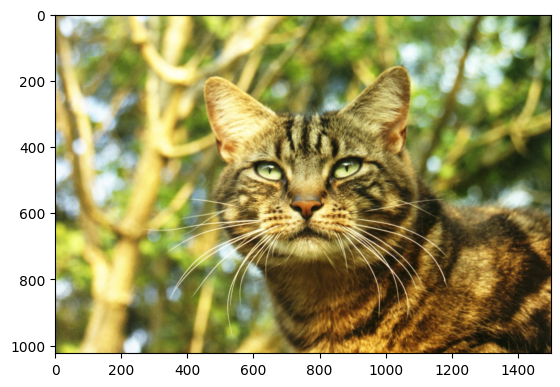

In [7]:
test_img=Image.open('img/cat.jpg')
test_img_data=np.asarray(test_img)
plt.imshow(test_img_data)
plt.show()

ResNet model trained on ImageNet dataset, expects images to be of a certain size, with channel data normalized to specific range of values. Need list of human-readable labels for categoris

In [9]:
transform=transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

transform.normalize=transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

transformed_img=transform(test_img)
input_img=transform.normalize(transformed_img).unsqueeze(0)

labels_path="img/imagenet_class_index.json"
with open(labels_path) as json_data:
    idx_to_labels=json.load(json_data)

what is our image

In [10]:
output=model(input_img)
output=F.softmax(output, dim=1)
prediction_score, pred_label_idx=torch.topk(output, 1)
pred_label_idx.squeeze_()
predicted_label=idx_to_labels[str(pred_label_idx.item())][1]
print("Predicted label: ", predicted_label, " (", prediction_score.squeeze().item(), ")")

Predicted label:  tabby  ( 0.6249904632568359 )


Why does model think this is cat, turn to Captum

## Feature Attribution with Integrated graidents

attributes a particular ouput to feature of input. Here test img generate map of relative importance of each input.

Integrated Gradients one of the features in Captum. Assigns importance score to each input feature by approximating integral of gradients of model output with respect to inputs.

Understand what part of input image contributed to this output. 

Use Captum `visualize_image_attr()` function to see representation of importance map. We pass custom Matplotlib color map.

Running cell with `integrated_gradients.attribute()` call will usually take a minute or two



In [11]:
integrated_gradients=IntegratedGradients(model)
attributions_ig=integrated_gradients.attribute(input_img, target=pred_label_idx.item(), n_steps=200)

: 

In [ ]:
# Show the original image for comparison
_ = viz.visualize_image_attr(None, np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)), 
                      method="original_image", title="Original Image")

default_cmap = LinearSegmentedColormap.from_list('custom blue', 
                                                 [(0, '#ffffff'),
                                                  (0.25, '#0000ff'),
                                                  (1, '#0000ff')], N=256)

_ = viz.visualize_image_attr(np.transpose(attributions_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                             method='heat_map',
                             cmap=default_cmap,
                             show_colorbar=True,
                             sign='positive',
                             title='Integrated Gradients')

## Feature Attribution with Occlusion

Gradient-based attribution methods help to understand the model in terms of directly computing out the output changes with respect to the input. *Perturbation-based attribution* methods approach this more directly, by introducing changes to the output to measure the effect on the output. [**Occlusion**](https://captum.ai/api/occlusion.html) is one such method. It involves replacing sections of the input image, and examining the effect on the output signal.

Below, we set up Occlusion attribution. Similarly to configuring a convolutional neural network, you can specify the size of the target region, and a stride length to determine the spacing of individual measurements. We'll visualize the output of our Occlusion attribution with `visualize_image_attr_multiple()`, showing heat maps of both positive and negative attribution by region, and by masking the original image with the positive attribution regions. The masking gives a very instructive view of what regions of our cat photo the model found to be most "cat-like".

In [ ]:
occlusion = Occlusion(model)

attributions_occ = occlusion.attribute(input_img,
                                       target=pred_label_idx,
                                       strides=(3, 8, 8),
                                       sliding_window_shapes=(3,15, 15),
                                       baselines=0)


In [ ]:
_ = viz.visualize_image_attr_multiple(np.transpose(attributions_occ.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      np.transpose(transformed_img.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      ["original_image", "heat_map", "heat_map", "masked_image"],
                                      ["all", "positive", "negative", "positive"],
                                      show_colorbar=True,
                                      titles=["Original", "Positive Attribution", "Negative Attribution", "Masked"],
                                      fig_size=(18, 6)
                                     )

## Layer Attribution with Layer GradCAM

Attribute activity of hidden layers within your model to features of your input. Computes gradients of target output with respect to given layer, avverages for each output channel, multiplies average graident for each channel by layer activations. Results summed over all channels. GradCAM designed for convnets. GradCAM attribution often unsample used to mask the input. 

Layer attribution similar to input attribution, except that in addition to the model, must specify a hidden layer within the model that you wish to examine. call `attribute()` we specify the target class of interest. 

In [ ]:
layer_gradcam=LayerGradCam(model, model.layer3[1].conv3)
attribution_lgc=layer_gradcam.attribute(input_img, target=pred_label_idx)

In [ ]:
_ = viz.visualize_image_attr(np.transpose(attribution_lgc.squeeze().cpu().detach().numpy(), (1,2,0)),
                             sign="all",
                             title="Layer Grad-CAM")

use convenience method `interpolate()` in LayerAttribution base class to upsample this attribution data for comparison to input image

In [ ]:
upsamp_attr_lgc=LayerAttribution.interpolate(attribution_lgc, transformed_img.shape[2:])

print(attribution_lgc.shape)
print(upsamp_attr_lgc.shape)
print(input_img.shape) 

_ = viz.visualize_image_attr(np.transpose(upsamp_attr_lgc.squeeze().cpu().detach().numpy(), (1,2,0)),
                             transformed_img.squeeze().cpu().detach().numpy().transpose(1,2,0),
                             ["original_image", "heat_map", "Masked Image"],
                             ["all", "positive", "positive"],
                             show_colorbar=True,
                             titles=["Original", "Layer Grad-CAM", "Masked"],
                             fig_size=(18, 6))

visualizations can give novel insights into how hidden layers respond to your output

##  Visualization with Captum Insights

Captum Insights is an interpretability visualization widget built on top of Captum to facilitate model understanding. Captum Insights works across images, text, and other features to help users understand feature attribution. It allows you to visualize attribution for multiple input/output pairs, and provides visualization tools for image, text, and arbitrary data.

In this section of the notebook, we'll visualize multiple image classification inferences with Captum Insights.

First, let's gather some image and see what the model thinks of them. For variety, we'll take our cat, a teapot, and a trilobite fossil:

In [ ]:
imgs = ['img/cat.jpg', 'img/teapot.jpg', 'img/trilobite.jpg']

for img in imgs:
    img = Image.open(img)
    transformed_img = transform(img)
    input_img = transform_normalize(transformed_img)
    input_img = input_img.unsqueeze(0) # the model requires a dummy batch dimension

    output = model(input_img)
    output = F.softmax(output, dim=1)
    prediction_score, pred_label_idx = torch.topk(output, 1)
    pred_label_idx.squeeze_()
    predicted_label = idx_to_labels[str(pred_label_idx.item())][1]
    print('Predicted:', predicted_label, '/', pred_label_idx.item(), ' (', prediction_score.squeeze().item(), ')')

...and it looks like our model is identifying them all correctly - but of course, we want to dig deeper. For that we'll use the Captum Insights widget, which we configure with an `AttributionVisualizer` object, imported below. The `AttributionVisualizer` expects batches of data, so we'll bring in Captum's `Batch` helper class. And we'll be looking at images specifically, so well also import `ImageFeature`.

We configure the `AttributionVisualizer` with the following arguments:

* An array of models to be examined (in our case, just the one)
* A scoring function, which allows Captum Insights to pull out the top-k predictions from a model
* An ordered, human-readable list of classes our model is trained on
* A list of features to look for - in our case, an `ImageFeature`
* A dataset, which is an iterable object returning batches of inputs and labels - just like you'd use for training

from captum.insights import AttributionVisualizer, Batch
from captum.insights.attr_vis.features import ImageFeature

# Baseline is all-zeros input - this may differ depending on your data
def baseline_func(input):
    return input * 0

# merging our image transforms from above
def full_img_transform(input):
    i = Image.open(input)
    i = transform(i)
    i = transform_normalize(i)
    i = i.unsqueeze(0)
    return i


input_imgs = torch.cat(list(map(lambda i: full_img_transform(i), imgs)), 0)

visualizer = AttributionVisualizer(
    models=[model],
    score_func=lambda o: torch.nn.functional.softmax(o, 1),
    classes=list(map(lambda k: idx_to_labels[k][1], idx_to_labels.keys())),
    features=[
        ImageFeature(
            "Photo",
            baseline_transforms=[baseline_func],
            input_transforms=[],
        )
    ],
    dataset=[Batch(input_imgs, labels=[282,849,69])]
)

Note that running the cell above didn't take much time at all, unlike our attributions above. That's because Captum Insights lets you configure different attribution algorithms in a visual widget, after which it will compute and display the attributions. *That* process will take a few minutes.

Running the cell below will render the Captum Insights widget. You can then choose attributions methods and their arguments, filter model responses based on predicte class or prediction correctness, see the model's predictions with associated probabilities, and view heatmaps of the attribution compared with the original image.

In [ ]:
visualizer.render()